In [1]:
#loading python classes and packages
import pandas as pd
import numpy as np
from string import punctuation
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
import pickle
from nltk.stem import PorterStemmer
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer #loading tfidf vector
from sklearn.metrics import accuracy_score
from keras.callbacks import ModelCheckpoint 
from keras.layers import Bidirectional, GRU, LSTM, Conv1D, MaxPooling1D, RepeatVector, GlobalAveragePooling1D#loading GRU, bidriectional, lstm and CNN
from sklearn.model_selection import train_test_split
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.models import Sequential, Model, load_model
from keras.utils.np_utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt  
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

Using TensorFlow backend.
c:\users\skbis\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\skbis\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\skbis\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [2]:
#defining NLTK objects to clean question text data
#define object to remove stop words and other text processing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
ps = PorterStemmer()

In [3]:
#define function to clean text by removing stop words and other special symbols
def cleanText(doc):
    tokens = doc.split()
    table = str.maketrans('', '', punctuation)
    tokens = [w.translate(table) for w in tokens]
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [w for w in tokens if not w in stop_words]
    tokens = [word for word in tokens if len(word) > 1]
    tokens = [ps.stem(token) for token in tokens]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = ' '.join(tokens)
    return tokens

In [4]:
#loading and displaying mendely SMS smishing dataset
mendely_dataset = pd.read_csv("Dataset/Dataset_5971.csv")
mendely_dataset

,LABEL,TEXT,URL,EMAIL,PHONE
0,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,No,No,No
1,ham,What's up? Do you want me to come online? If y...,No,No,No
2,ham,So u workin overtime nigpun?,No,No,No
3,ham,"Also sir, i sent you an email about how to log...",No,No,No
4,Smishing,Please Stay At Home. To encourage the notion o...,No,No,No
...,...,...,...,...,...
5966,ham,:( but your not here....,No,No,No
5967,ham,Becoz its &lt;#&gt; jan whn al the post ofic...,No,No,No
5968,ham,Its a valentine game. . . send dis msg to all ...,No,No,No
5969,ham,We r outside already.,No,No,No


In [5]:
#loading and displaying Kaggle SMS smishing dataset
kaggle_dataset = pd.read_csv("Dataset/kaggle_smishing.csv", encoding = "ISO-8859-1")
kaggle_dataset

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [6]:
#defining global variables to add processed text and labels
X = []
Y = []

In [7]:
#defining function to loop and read each SMS and then clean and return process text to extract features
def loadDataset(sms_text, labels):
    for i in range(len(sms_text)):#loop each sms from given dataset sms texy
        sms = str(sms_text[i])
        sms = sms.strip("\n").strip().lower()#convert sms to lower and remove empty text
        if len(sms) > 0:
            label = labels[i].strip().lower()
            sms = cleanText(sms)#clean SMS text and add to X and Y training array
            X.append(sms)
            if label == "ham":
                Y.append(0)
            else:
                Y.append(1)

In [8]:
#if sms already cleaned then load them else processed and load them
if os.path.exists("model/X.npy"):
    X = np.load("model/X.npy")
    Y = np.load("model/Y.npy")
else:
    #extract labels and text from both dataset and then clean them
    sms_text = mendely_dataset['TEXT'].ravel()
    labels = mendely_dataset['LABEL'].ravel()
    loadDataset(sms_text, labels)#calling function to clean mendely dataset
    sms_text = kaggle_dataset['v2'].ravel()
    labels = kaggle_dataset['v1'].ravel()
    loadDataset(sms_text, labels)#calling function to clean KAGGLE dataset
    X = np.asarray(X)
    Y = np.asarray(Y)
    np.save("model/X", X)
    np.save("model/Y", Y)
print("Dataset SMS Cleaning & Processing Completed")
print("Total SMS found in Dataset = "+str(X.shape[0]))

Dataset SMS Cleaning & Processing Completed
Total SMS found in Dataset = 11543


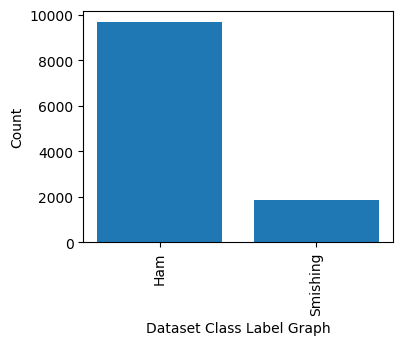

In [9]:
#visualizing graph of number of duplicate and non-duplicate (isolate) questions
labels, count = np.unique(Y, return_counts = True)
height = count
bars = ['Ham', 'Smishing']
y_pos = np.arange(len(bars))
plt.figure(figsize = (4, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [10]:
#extracting features from SMS text using TFIDF vector
tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words, use_idf=True, smooth_idf=False, norm=None, decode_error='replace', max_features=768)
X = tfidf_vectorizer.fit_transform(X).toarray()
print("TF-IDF Extracted Features = "+str(X))

TF-IDF Extracted Features = [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [11]:
#applying dataset processing such as shuffling and normalizing TFIDF features
sc = StandardScaler()
X = sc.fit_transform(X)#normalize features using Standard scaler Algorithm
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle features
X = X[indices]
Y = Y[indices]
Y = to_categorical(Y)
print("Normalized Features = "+str(X))

Normalized Features = [[-0.06727021 -0.06260627 -0.0395199  ... -0.05909001 -0.08613012
  -0.06368084]
 [-0.06727021 -0.06260627 -0.0395199  ... -0.05909001 -0.08613012
  -0.06368084]
 [-0.06727021 -0.06260627 -0.0395199  ... -0.05909001 -0.08613012
  -0.06368084]
 ...
 [-0.06727021 -0.06260627 -0.0395199  ... -0.05909001 -0.08613012
  -0.06368084]
 [-0.06727021 -0.06260627 -0.0395199  ... -0.05909001 -0.08613012
  -0.06368084]
 [-0.06727021 -0.06260627 -0.0395199  ... -0.05909001 -0.08613012
  -0.06368084]]


In [12]:
#split TF-IDF features into train and test
X1 = np.reshape(X, (X.shape[0], 32, 24))
X_train, X_test, y_train, y_test = train_test_split(X1, Y, test_size=0.2)
print("Dataset Train & Test Split Details")
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Dataset Train & Test Split Details
80% records used to train algorithms : 9234
20% records used to test algorithms : 2309


In [13]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [14]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    labels = ['Ham', 'Smishing']
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show() 


Existing BI-LSTM Accuracy  : 98.48419229103507
Existing BI-LSTM Precision : 98.05068183475534
Existing BI-LSTM Recall    : 96.22604579115887
Existing BI-LSTM FSCORE    : 97.11067183359987


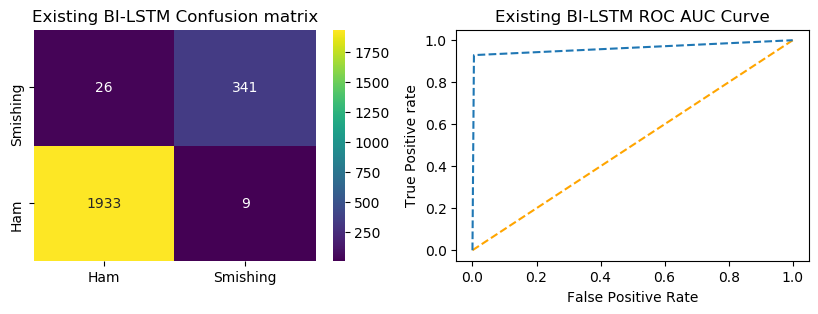

In [15]:
#training existing BILSTM algorithm
bilstm_model = Sequential()
#adding Bidirectional LSTM layer with 32 neurons
bilstm_model.add(Bidirectional(LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2]))))
bilstm_model.add(Dense(16, activation='relu'))
#defining output predictin layer
bilstm_model.add(Dense(y_train.shape[1], activation='softmax'))
#compiling, training and loading model
bilstm_model.compile(loss='categorical_crossentropy', optimizer="adam", metrics=['accuracy'])
if os.path.exists("model/bilstm_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/bilstm_weights.hdf5', verbose = 1, save_best_only = True)
    hist = bilstm_model.fit(X_train, y_train, batch_size = 32, epochs = 25, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/bilstm_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    bilstm_model = load_model("model/bilstm_weights.hdf5")
#perform prediction on test data   
predict = bilstm_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call function to calculate accuracy and other metrics
calculateMetrics("Existing BI-LSTM", y_test1, predict)

Existing GRU Accuracy  : 98.44088349935038
Existing GRU Precision : 98.36239393301283
Existing GRU Recall    : 95.75832662189883
Existing GRU FSCORE    : 97.00419507835139


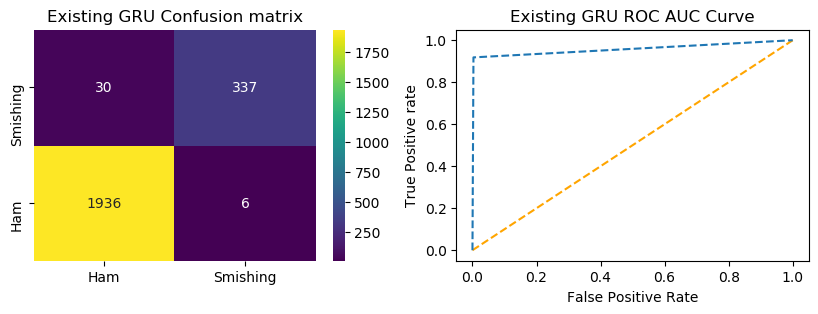

In [16]:
#now train existing GRU algorithm
gru_model = Sequential() #defining deep learning sequential object
#adding GRU layer with 32 filters to filter given input X train data to select relevant features
gru_model.add(GRU(32, input_shape=(X_train.shape[1], X_train.shape[2])))
#defining output layer for prediction
gru_model.add(Dense(y_train.shape[1], activation='softmax'))
#compile GRU model
gru_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#start training model on train data and perform validation on test data
if os.path.exists("model/gru_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/gru_weights.hdf5', verbose = 1, save_best_only = True)
    hist = gru_model.fit(X_train, y_train, batch_size = 32, epochs = 25, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/gru_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close() 
else:
    gru_model = load_model("model/gru_weights.hdf5")
predict = gru_model.predict(X_test)#perfrom prediction on test data
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call function to calculate accuracy and other metrics
calculateMetrics("Existing GRU", y_test1, predict)

Existing LSTM Accuracy  : 98.78735383282806
Existing LSTM Precision : 99.0472137118181
Existing LSTM Recall    : 96.4062723617047
Existing LSTM FSCORE    : 97.6699295053844


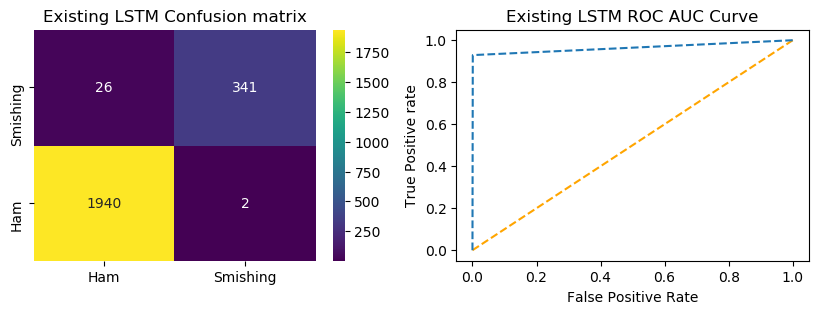

In [17]:
#now train existing LSTM algorithm
lstm_model = Sequential() #defining deep learning sequential object
#adding LSTN layer with 32 filters to filter given input X train data to select relevant features
lstm_model.add(LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2])))
#defining output layer for prediction
lstm_model.add(Dense(y_train.shape[1], activation='softmax'))
#compile GRU model
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#start training model on train data and perform validation on test data
if os.path.exists("model/lstm_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm_weights.hdf5', verbose = 1, save_best_only = True)
    hist = lstm_model.fit(X_train, y_train, batch_size = 32, epochs = 25, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/lstm_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close() 
else:
    lstm_model = load_model("model/lstm_weights.hdf5")
predict = lstm_model.predict(X_test)#perfrom prediction on test data
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call function to calculate accuracy and other metrics
calculateMetrics("Existing LSTM", y_test1, predict)


Propose CNN + LSTM Accuracy  : 98.83066262451278
Propose CNN + LSTM Precision : 99.31437277805992
Propose CNN + LSTM Recall    : 96.32152588555857
Propose CNN + LSTM FSCORE    : 97.74534307724522


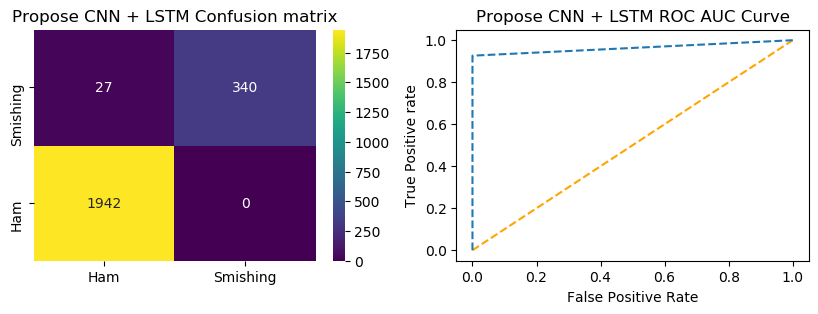

In [18]:
#training propose CNN-LSTM algorithm by combining both models where CNN used to extract optimized features and LSTM
#will train on optimized features for accurate classification and to reduce false positive rate
cnn_lstm = Sequential()
#adding CNN layer
cnn_lstm.add(Conv1D(filters=32, kernel_size = 3, activation = 'relu', input_shape = (X_train.shape[1], X_train.shape[2])))
#adding maxpool layer
cnn_lstm.add(MaxPooling1D(pool_size = 2))
cnn_lstm.add(LSTM(16, return_sequences=True)) # ========adding LSTM layer
cnn_lstm.add(Flatten())
cnn_lstm.add(RepeatVector(2))
cnn_lstm.add(GlobalAveragePooling1D())
cnn_lstm.add(Dropout(0.3))
#defining output layer
cnn_lstm.add(Dense(units = 16, activation = 'softmax'))
cnn_lstm.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compile and train the model
cnn_lstm.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_lstm_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_lstm_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_lstm.fit(X_train, y_train, batch_size = 32, epochs = 25, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_lstm_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_lstm.load_weights("model/cnn_lstm_weights.hdf5")
#perform prediction on test data using SmoteTomek and CNN1D
predict = cnn_lstm.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call function to calculate accuracy and other metrics
calculateMetrics("Propose CNN + LSTM", y_test1, predict)

Extension CNN + LSTM + Bidirectional Accuracy  : 98.96058899956691
Extension CNN + LSTM + Bidirectional Precision : 99.2695327489005
Extension CNN + LSTM + Bidirectional Recall    : 96.84073836068886
Extension CNN + LSTM + Bidirectional FSCORE    : 98.00738707951466


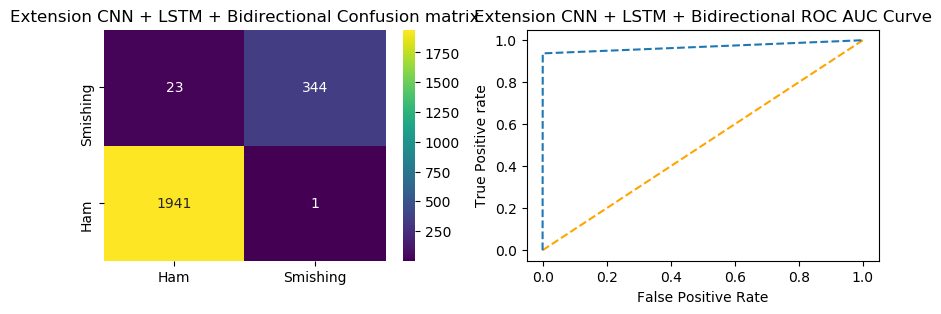

In [19]:
#implementing extension algorithm by combining 3 different models such as CNN + LSTM + Bidirectional where cnn will be used
#to optimize features and LSTM will train on optimize features by taking Bidirectional help which improves 
#LSTM accuracy by increasing the amount of information available to the network
extension_cnn_bilstm = Sequential()
#defining CNN layer
extension_cnn_bilstm.add(Conv1D(filters=32, kernel_size = 3, activation = 'relu', input_shape = (X_train.shape[1], X_train.shape[2])))
#adding maxpool layer
extension_cnn_bilstm.add(MaxPooling1D(pool_size = 2))
# adding Bidirectional LSTM layer
extension_cnn_bilstm.add(Bidirectional(LSTM(16, return_sequences=True)))
extension_cnn_bilstm.add(Flatten())
extension_cnn_bilstm.add(RepeatVector(2))
extension_cnn_bilstm.add(GlobalAveragePooling1D())
extension_cnn_bilstm.add(Dropout(0.2))
#defining output layer
extension_cnn_bilstm.add(Dense(units = 16, activation = 'relu'))
extension_cnn_bilstm.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compile and train the model
extension_cnn_bilstm.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/extension_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/extension_weights.hdf5', verbose = 1, save_best_only = True)
    hist = extension_cnn_bilstm.fit(X_train, y_train, batch_size = 32, epochs = 25, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/extension_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    extension_cnn_bilstm.load_weights("model/extension_weights.hdf5")
#perform prediction on test data using SmoteTomek and CNN1D
predict = extension_cnn_bilstm.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call function to calculate accuracy and other metrics
calculateMetrics("Extension CNN + LSTM + Bidirectional", y_test1, predict)

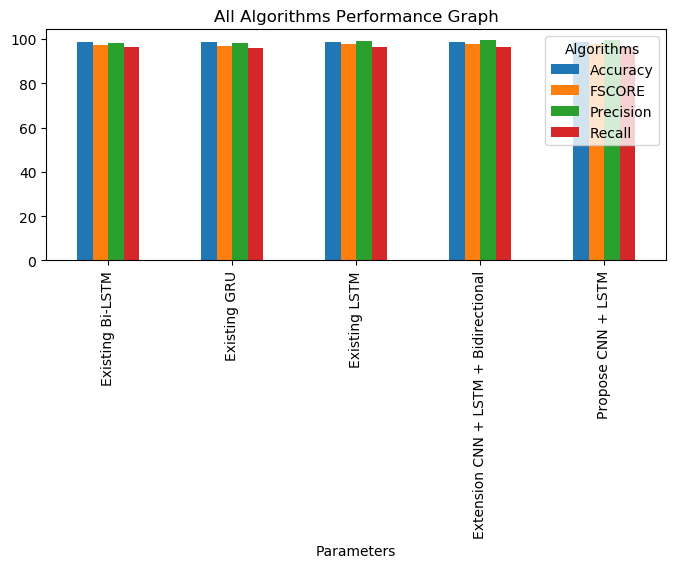

In [20]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['Existing Bi-LSTM','Accuracy',accuracy[0]],['Existing Bi-LSTM','Precision',precision[0]],['Existing Bi-LSTM','Recall',recall[0]],['Existing Bi-LSTM','FSCORE',fscore[0]],
                   ['Existing GRU','Accuracy',accuracy[1]],['Existing GRU','Precision',precision[1]],['Existing GRU','Recall',recall[1]],['Existing GRU','FSCORE',fscore[1]],
                   ['Existing LSTM','Accuracy',accuracy[2]],['Existing LSTM','Precision',precision[2]],['Existing LSTM','Recall',recall[2]],['Existing LSTM','FSCORE',fscore[2]],
                   ['Propose CNN + LSTM','Accuracy',accuracy[3]],['Propose CNN + LSTM','Precision',precision[3]],['Propose CNN + LSTM','Recall',recall[3]],['Propose CNN + LSTM','FSCORE',fscore[3]],
                   ['Extension CNN + LSTM + Bidirectional','Accuracy',accuracy[3]],['Extension CNN + LSTM + Bidirectional','Precision',precision[3]],['Extension CNN + LSTM + Bidirectional','Recall',recall[3]],['Extension CNN + LSTM + Bidirectional','FSCORE',fscore[3]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [21]:
#display all algorithm performnace
algorithms = ['Existing Bi-LSTM', 'Existing GRU', 'Existing LSTM', 'Propose CNN + LSTM', 'Extension CNN + LSTM + Bidirectional']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data 

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Existing Bi-LSTM,98.484192,98.050682,96.226046,97.110672
1,Existing GRU,98.440883,98.362394,95.758327,97.004195
2,Existing LSTM,98.787354,99.047214,96.406272,97.669930
3,Propose CNN + LSTM,98.830663,99.314373,96.321526,97.745343
4,Extension CNN + LSTM + Bidirectional,98.960589,99.269533,96.840738,98.007387


In [22]:
#performing prediction on real test data
labels = ['Ham', 'Smishing']
dataset = pd.read_csv('Dataset/testData.csv', encoding = "ISO-8859-1")#loading test data
temp = dataset.values.copy()
data = dataset['TEXT'].ravel()
for i in range(len(data)): #looping and cleaning each TEST SMS
    sms = data[i].strip("\n").strip().lower()
    sms = cleanText(sms)#clean description
    data[i] = sms
data = tfidf_vectorizer.transform(data).toarray()   #extracting features from SMS using TFIDF features  
data = sc.transform(data) #normalizing test features
data = np.reshape(data, (data.shape[0], 32, 24))
predict = extension_cnn_bilstm.predict(data)#applying extension model to predict SMS as HAM or Smishing
predict = np.argmax(predict, axis=1)
for i in range(len(predict)):
    print("Test Data = "+str(temp[i,0])+" Predicted As ====> "+labels[predict[i]]+"\n")

Test Data = Think ur smart ? Win å£200 this week in our weekly quiz, text PLAY to 85222 now!T&Cs WinnersClub PO BOX 84, M26 3UZ. 16+. GBP1.50/week Predicted As ====> Smishing

Test Data = He says he'll give me a call when his friend's got the money but that he's definitely buying before the end of the week Predicted As ====> Ham

Test Data = Hi the way I was with u 2day, is the normal way&this is the real me. UR unique&I hope I know u 4 the rest of mylife. Hope u find wot was lost. Predicted As ====> Ham

Test Data = You made my day. Do have a great day too. Predicted As ====> Ham

Test Data = December only! Had your mobile 11mths+? You are entitled to update to the latest colour camera mobile for Free! Call The Mobile Update Co FREE on 08002986906 Predicted As ====> Smishing

Test Data = Dear 0776xxxxxxx U've been invited to XCHAT. This is our final attempt to contact u! Txt CHAT to 86688 150p/MsgrcvdHG/Suite342/2Lands/Row/W1J6HL LDN 18yrs Predicted As ====> Smishing

Test Data = Have

In [23]:
#=================flask code starts here
from flask import Flask, render_template, request, redirect, url_for, session,send_from_directory

In [24]:
app = Flask(__name__)
app.secret_key = 'welcome'

In [25]:
def getModel():
    extension_cnn_bilstm = Sequential()
    #defining CNN layer
    extension_cnn_bilstm.add(Conv1D(filters=32, kernel_size = 3, activation = 'relu', input_shape = (32, 24)))
    #adding maxpool layer
    extension_cnn_bilstm.add(MaxPooling1D(pool_size = 2))
    # adding Bidirectional LSTM layer
    extension_cnn_bilstm.add(Bidirectional(LSTM(16, return_sequences=True)))
    extension_cnn_bilstm.add(Flatten())
    extension_cnn_bilstm.add(RepeatVector(2))
    extension_cnn_bilstm.add(GlobalAveragePooling1D())
    extension_cnn_bilstm.add(Dropout(0.2))
    #defining output layer
    extension_cnn_bilstm.add(Dense(units = 16, activation = 'relu'))
    extension_cnn_bilstm.add(Dense(units = 2, activation = 'softmax'))
    #compile and train the model
    extension_cnn_bilstm.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    extension_cnn_bilstm.load_weights("model/extension_weights.hdf5")
    return extension_cnn_bilstm
        
@app.route('/Predict', methods=['GET', 'POST'])
def predictView():
    return render_template('Predict.html', msg='')

@app.route('/index', methods=['GET', 'POST'])
def index():
    return render_template('index.html', msg='')

@app.route('/AdminLogin', methods=['GET', 'POST'])
def AdminLogin():
    return render_template('AdminLogin.html', msg='')

@app.route('/AdminLoginAction', methods=['GET', 'POST'])
def AdminLoginAction():
    if request.method == 'POST' and 't1' in request.form and 't2' in request.form:
        user = request.form['t1']
        password = request.form['t2']
        if user == "admin" and password == "admin":
            return render_template('AdminScreen.html', msg="Welcome "+user)
        else:
            return render_template('AdminLogin.html', msg="Invalid login details")

@app.route('/Logout')
def Logout():
    return render_template('index.html', msg='')

@app.route('/PredictAction', methods=['GET', 'POST'])
def PredictAction():   
    if request.method == 'POST':
        file = request.files['t1']
        extension_model = getModel()
        labels = ['Ham', 'Smishing']
        dataset = pd.read_csv('Dataset/testData.csv', encoding = "ISO-8859-1")#loading test data
        temp = dataset.values.copy()
        data = dataset['TEXT'].ravel()
        for i in range(len(data)): #looping and cleaning each TEST SMS
            sms = data[i].strip("\n").strip().lower()
            sms = cleanText(sms)#clean description
            data[i] = sms
        data = tfidf_vectorizer.transform(data).toarray()   #extracting features from SMS using TFIDF features  
        data = sc.transform(data) #normalizing test features
        data = np.reshape(data, (data.shape[0], 32, 24))
        predict = extension_model.predict(data)#applying extension model to predict SMS as HAM or Smishing
        predict = np.argmax(predict, axis=1)
        output = ""
        for i in range(len(predict)):
            output += "Test Data = "+str(temp[i, 0])+" Predicted As ====> "+labels[predict[i]]+"<br/><br/>"
        return render_template('AdminScreen.html', msg=output)

In [ ]:
if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__' (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [13/May/2026 10:36:37] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [13/May/2026 10:36:37] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [13/May/2026 10:36:41] "GET /index HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 10:36:41] "GET /static/images/tra.jpg HTTP/1.1" 304 -
127.0.0.1 - - [13/May/2026 10:36:41] "GET /static/default.css HTTP/1.1" 304 -
127.0.0.1 - - [13/May/2026 10:36:41] "GET /static/images/img02.jpg HTTP/1.1" 404 -
127.0.0.1 - - [13/May/2026 10:36:41] "GET /static/images/back.jpg HTTP/1.1" 304 -
127.0.0.1 - - [13/May/2026 10:36:41] "GET /static/images/img05.jpg HTTP/1.1" 304 -
127.0.0.1 - - [13/May/2026 10:36:41] "GET /static/images/img03.jpg HTTP/1.1" 304 -
127.0.0.1 - - [13/May/2026 10:36:41] "GET /static/images/bg.jpg HTTP/1.1" 304 -
127.0.0.1 - - [13/May/2026 10:37:46] "GET /AdminLogin HTTP/1.1" 200 -
127.0.0.1 - - [13/May/2026 10:37:46] "GET /static/default.css HTTP/1.1" 304 -
127.0.0.1 - - [13/May/2026 10